# Pure Weber Balancing Act: Sub-Critical Positive Pair Stabilised by Super-Critical Negative Pair

This notebook demonstrates a four-body configuration in **pure Weber electrodynamics
(no Zöllner extension)** where two sub-critical like charges — which would otherwise
collapse to a singularity — are stabilised by two nearby opposite charges in the
super-critical regime.

## Physics Background

### Weber's Force Law and the Critical Radius

Weber's force between charges $q_i$, $q_j$ separated by $r$ is

$$F = \frac{q_i q_j}{r^2}\left(1 - \frac{\dot{r}^2}{2c^2} + \frac{r\ddot{r}}{c^2}\right)$$

The velocity-dependent terms introduce an **effective inertial mass**

$$\mu_{\text{eff}}(r) = \mu\left(1 - \frac{\rho}{r}\right), \qquad \rho = \frac{q_i q_j}{\mu c^2}$$

For two like charges ($q_i q_j > 0$), $\rho > 0$ is the **critical radius**.  
At $r < \rho$ (sub-critical) the effective mass is **negative**: the pair attracts
instead of repelling.

### The Frauenfelder Non-Regularisability Result

Frauenfelder & Weber (2024) prove that a sub-critical like-charge pair with nonzero angular
momentum ($\ell \neq 0$) spirals inward with **infinitely many windings** in finite time — a
topological obstruction that **no regularisation can remove** (Theorem 2.1 of
[arXiv:2310.11560](https://link.springer.com/article/10.1007/s13324-024-00889-5)).

Only the head-on ($\ell = 0$) case admits regularisation, via a hard bounce reflection
(`regularization_collision_bounce_radius`) that continues the trajectory through $r = 0$.

**Consequence**: two sub-critical positive charges released from rest collapse and
crash (retcode `Failure`) within $\sim 0.009$ time units.

### The Balancing Hypothesis

Two negative charges placed close to the positive pair are in the **super-critical
regime** ($r_{--} > \rho$): they repel each other normally and are held together by
attraction to the positive pair. In a binary-molecule arrangement (positive pair at
$y = -R/2$, negative pair at $y = +R/2$), all four particles share the same initial
velocity — so the positive pair's **internal relative velocity is zero**, placing them
in the head-on ($\ell = 0$) regime that admits bounce regularisation.

The negative pair keeps the system gravitationally (electrostatically) bound;
the bounce prevents the sub-critical singularity.

| Particle | Charge | Pair | Regime |
|---|---|---|---|
| 1 | $+q$ | A | Sub-critical ($r_A < \rho$) |
| 2 | $+q$ | A | Sub-critical ($r_A < \rho$) |
| 3 | $-q$ | B | Super-critical ($r_B > \rho$) |
| 4 | $-q$ | B | Super-critical ($r_B > \rho$) |

**No Zöllner extension** is used — all pair couplings $\kappa_{ij} = 1$.

**References**: Frauenfelder & Weber, *Anal. Math. Phys.* **14**:31 (2024); Weber,
Sixth Memoir (1871) §§9.8–9.17; see `research/theory/` and
`research/sub_critical_weber_research/`.

In [1]:
using WeberElectrodynamics
using LinearAlgebra
using Printf
using Plots

## 1. Physical Parameters

In [2]:
m  = 1.0    # particle mass
q  = 1.0    # charge magnitude
c  = 4.0    # Weber speed constant

μ  = m * m / (m + m)      # reduced mass = 0.5
ρ  = q^2  / (μ * c^2)    # critical radius = 0.125

# Pair A: positive, sub-critical
r_A      = 0.060           # initial internal separation
bounce_r = 0.018           # ℓ=0 bounce radius

# Pair B: negative, super-critical
r_B = 0.180

# Binary geometry
R  = 0.200                 # pair COM-to-COM separation
η  = 1.0                   # fraction of circular orbital speed

# Binary orbit speed
μ_bin  = m                 # binary reduced mass (pair masses 2m each → μ_bin = m)
Q_eff  = 4 * q^2           # effective inter-pair charge product (4 unlike-charge pairs)
v_circ = sqrt(Q_eff / (μ_bin * R))
v_orb  = η * v_circ / 2    # speed of each individual particle
T_orb  = 2π * R / v_circ   # binary orbital period

# Integration
dt     = 2e-5
tspan  = (0.0, 1.0)
stride = 50

system = WeberSystem(4, 2)

@printf("Critical radius ρ = %.4f\n\n", ρ)
@printf("Pair A (positive):  r_A = %.3f  < ρ  →  sub-critical   bounce_r = %.3f\n", r_A, bounce_r)
@printf("Pair B (negative):  r_B = %.3f  > ρ  →  super-critical\n\n", r_B)
@printf("Binary geometry:    R = %.3f   η = %.1f\n", R, η)
@printf("                    v_circ = %.4f   v_orb = %.4f   T_orb ≈ %.4f\n\n", v_circ, v_orb, T_orb)
@printf("Integration:        dt = %.0e   tspan = (%.1f, %.1f)   stride = %d\n",
    dt, tspan[1], tspan[2], stride)

Critical radius ρ = 0.1250

Pair A (positive):  r_A = 0.060  < ρ  →  sub-critical   bounce_r = 0.018
Pair B (negative):  r_B = 0.180  > ρ  →  super-critical

Binary geometry:    R = 0.200   η = 1.0
                    v_circ = 4.4721   v_orb = 2.2361   T_orb ≈ 0.2810

Integration:        dt = 2e-05   tspan = (0.0, 1.0)   stride = 50


## 2. Initial Conditions and Problem Setup

The **binary molecule** geometry places pair A (positive) at the bottom ($y = -R/2$)
and pair B (negative) at the top ($y = +R/2$), each pair's internal axis along $x$.
Both particles within each pair receive the **same** velocity $v_{\text{orb}}$,
so their internal relative velocity is zero — the positive pair begins in purely
radial ($\ell = 0$) motion, satisfying the bounce regularisation condition.

In [3]:
# Binary molecule ICs
x1 = -r_A/2;  y1 = -R/2
x2 = +r_A/2;  y2 = -R/2
x3 = -r_B/2;  y3 = +R/2
x4 = +r_B/2;  y4 = +R/2

# Pair A moves +x, pair B moves −x → counterclockwise binary orbit
q0 = [x1, y1, x2, y2, x3, y3, x4, y4]
p0 = [m*v_orb, 0.0, m*v_orb, 0.0, -m*v_orb, 0.0, -m*v_orb, 0.0]

prob = WeberProblem(system, tspan, q0, p0;
    masses  = [m, m, m, m],
    charges = [q, q, -q, -q],
    c       = c,
    dt      = dt,
    regularization_enabled               = false,
    regularization_collision_bounce_radius = bounce_r,
    zollner_enabled = false)

@printf("Kappas (all 1.0 — no Zöllner): %s\n\n",
    join([@sprintf("%.1f", k) for k in prob.kappas], ", "))
@printf("Initial separations:\n")
@printf("  r12 (P-P, pair A) = %.4f   (< ρ=%.4f → sub-critical)\n", r_A, ρ)
@printf("  r34 (N-N, pair B) = %.4f   (> ρ=%.4f → super-critical)\n", r_B, ρ)
@printf("  r13 (P-N cross)   = %.4f\n",
    sqrt((x1-x3)^2+(y1-y3)^2))

println("\nSolving...")
sol = solve(prob)
@printf("Done: %d steps, retcode = %s, t_end = %.4f\n",
    length(sol.t), string(sol.retcode), sol.t[end])

Kappas (all 1.0 — no Zöllner): 1.0, 1.0, 1.0, 1.0, 1.0, 1.0

Initial separations:
  r12 (P-P, pair A) = 0.0600   (< ρ=0.1250 → sub-critical)
  r34 (N-N, pair B) = 0.1800   (> ρ=0.1250 → super-critical)
  r13 (P-N cross)   = 0.2088

Solving...
Done: 50001 steps, retcode = Success, t_end = 1.0000


## 3. Trajectory

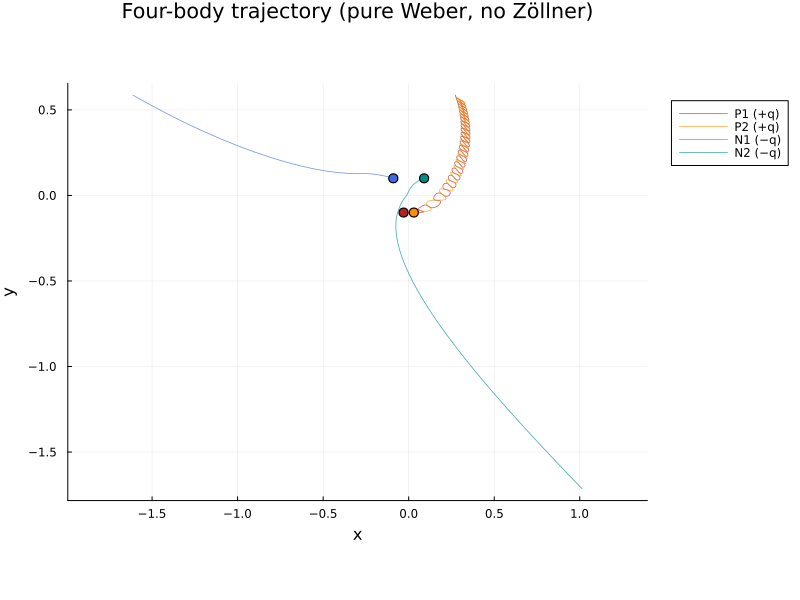

In [4]:
traj = compute_trajectory_data(sol, 4, 2; stride=stride)

colors = [:firebrick, :darkorange, :royalblue, :cyan4]
labels = ["P1 (+q)" "P2 (+q)" "N1 (−q)" "N2 (−q)"]

pl = plot(
    title  = "Four-body trajectory (pure Weber, no Zöllner)",
    xlabel = "x", ylabel = "y",
    aspect_ratio = :equal,
    legend = :outertopright,
    size   = (800, 600))

for i in 1:4
    xs = traj.trajectories[i][:, 1]
    ys = traj.trajectories[i][:, 2]
    plot!(pl, xs, ys; label=labels[i], color=colors[i], lw=0.8, alpha=0.7)
    scatter!(pl, [xs[1]], [ys[1]]; color=colors[i], ms=5, label=false)
end

pl

## 4. Positive-Pair Separation and Energy Conservation

Two diagnostics confirm the balancing mechanism:

1. **$r_{12}(t)$**: the positive-pair separation oscillates with $r_{12} > 0$ throughout —
   the bounce prevents the sub-critical singularity.
2. **Energy conservation**: total Weber energy stays close to its initial value.

r12 range:     0.0178 – 0.0666   (bounce_r = 0.0180)
Energy drift:  3.99%  (max global error)


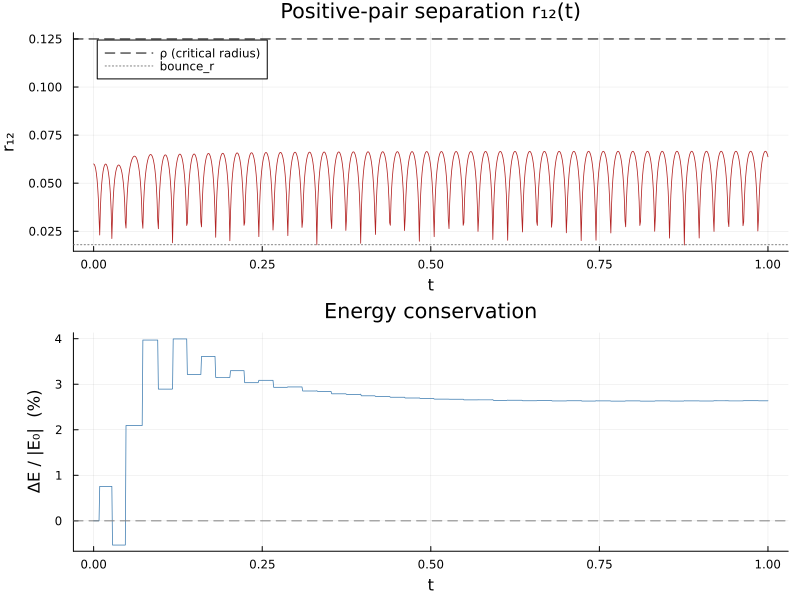

In [5]:
en = compute_energy_timeseries(sol; stride=stride)
t_plot = sol.t[1:stride:end]

# r12 from strided trajectory
r12 = [sqrt((traj.trajectories[1][k,1] - traj.trajectories[2][k,1])^2 +
            (traj.trajectories[1][k,2] - traj.trajectories[2][k,2])^2)
       for k in axes(traj.trajectories[1], 1)]

# Energy percent deviation from initial value
E0    = en.total_energy[1]
E_pct = 100 .* (en.total_energy .- E0) ./ abs(E0)

p1 = plot(t_plot, r12;
    xlabel = "t", ylabel = "r₁₂",
    title  = "Positive-pair separation r₁₂(t)",
    color  = :firebrick, lw = 0.8, label = false)
hline!(p1, [ρ]; ls=:dash, color=:black, label="ρ (critical radius)")
hline!(p1, [bounce_r]; ls=:dot, color=:gray, label="bounce_r")

p2 = plot(t_plot, E_pct;
    xlabel = "t", ylabel = "ΔE / |E₀|  (%)",
    title  = "Energy conservation",
    color  = :steelblue, lw = 0.8, label = false)
hline!(p2, [0.0]; ls=:dash, color=:gray, label=false)

@printf("r12 range:     %.4f – %.4f   (bounce_r = %.4f)\n",
    minimum(r12), maximum(r12), bounce_r)
@printf("Energy drift:  %.2f%%  (max global error)\n",
    en.statistics.global_error_percent_max)

plot(p1, p2; layout=(2,1), size=(800,600))